The purpose of this document is to give an estimate of companies by their mean document length values for their annual reports.

We hope to find trends in length across industries as well as isolate companies with particularly long reports

This is hoped to provide a tool for future normalisation of TF/IDF mean scoring, or as a heuristic oversight of the text volume extracted.

In [6]:
from __future__ import annotations
import polars as pl


# --------------------
# Config
# --------------------
PARQUET_FILE = "spy_10k_2015_present.parquet"
YEAR_START = 2015
YEAR_END = 2024
FORM_TYPE = "10-K"   # set to None to keep all forms


# --------------------
# Load parquet
# --------------------
df = pl.read_parquet(PARQUET_FILE)

# --------------------
# Derive year (THIS IS THE KEY FIX)
# --------------------
df = df.with_columns(
    pl.col("filing_date").dt.year().alias("year")
)

# --------------------
# Filter window
# --------------------
df = (
    df
    .filter((pl.col("year") >= YEAR_START) & (pl.col("year") <= YEAR_END))
    .filter(pl.col("text").is_not_null())
)

if FORM_TYPE is not None:
    df = df.filter(pl.col("form_type") == FORM_TYPE)


# --------------------
# Compute section-level document length
# --------------------
df = df.with_columns(
    pl.col("text").str.len_chars().alias("section_length")
)

# --------------------
# Collapse sections → filing (firm-year)
# --------------------
firm_year = (
    df
    .group_by(
        "cik",
        "ticker",
        "company_name",
        "gics_sector",
        "gics_sub_industry",
        "year",
    )
    .agg(
        pl.col("section_length").sum().alias("doc_length"),
        pl.count().alias("n_sections"),
    )
    .sort(["cik", "year"])
)

# --------------------
# Firm-level mean length + outliers
# --------------------
firm_summary = (
    firm_year
    .group_by(
        "cik",
        "ticker",
        "company_name",
        "gics_sector",
        "gics_sub_industry",
    )
    .agg(
        pl.col("doc_length").mean().alias("mean_doc_length"),
        pl.col("doc_length").median().alias("median_doc_length"),
        pl.col("doc_length").std().alias("sd_doc_length"),
        pl.count().alias("n_years"),
    )
    .filter(pl.col("n_years") >= 5)
)

mu = firm_summary["mean_doc_length"].mean()
sd = firm_summary["mean_doc_length"].std()

firm_summary = firm_summary.with_columns(
    ((pl.col("mean_doc_length") - mu) / sd).alias("z_mean_doc_length")
)

# --------------------
# Sector / industry trends
# --------------------
sector_ts = (
    firm_year
    .group_by("gics_sector", "year")
    .agg(
        pl.col("doc_length").median().alias("median_doc_length"),
        pl.col("doc_length").mean().alias("mean_doc_length"),
        pl.count().alias("n_firm_years"),
    )
    .sort(["gics_sector", "year"])
)

industry_ts = (
    firm_year
    .group_by("gics_sub_industry", "year")
    .agg(
        pl.col("doc_length").median().alias("median_doc_length"),
        pl.col("doc_length").mean().alias("mean_doc_length"),
        pl.count().alias("n_firm_years"),
    )
    .sort(["gics_sub_industry", "year"])
)


# --------------------
# Diagnostics
# --------------------
print("Firm–year panel:")
print(firm_year.head())

print("\nTop 10 longest firms (mean disclosure length):")
print(
    firm_summary
    .sort("mean_doc_length", descending=True)
    .select("cik", "mean_doc_length")
    .head(10)
)

print("\nTop 10 unusually verbose firms (z-score):")
print(
    firm_summary
    .sort("z_mean_doc_length", descending=True)
    .select("cik", "z_mean_doc_length")
    .head(10)
)


Firm–year panel:
shape: (5, 8)
┌────────────┬────────┬──────────────┬─────────────┬──────────────┬──────┬────────────┬────────────┐
│ cik        ┆ ticker ┆ company_name ┆ gics_sector ┆ gics_sub_ind ┆ year ┆ doc_length ┆ n_sections │
│ ---        ┆ ---    ┆ ---          ┆ ---         ┆ ustry        ┆ ---  ┆ ---        ┆ ---        │
│ str        ┆ str    ┆ str          ┆ str         ┆ ---          ┆ i32  ┆ u32        ┆ u32        │
│            ┆        ┆              ┆             ┆ str          ┆      ┆            ┆            │
╞════════════╪════════╪══════════════╪═════════════╪══════════════╪══════╪════════════╪════════════╡
│ 0000001800 ┆ ABT    ┆ Abbott       ┆ Health Care ┆ Health Care  ┆ 2015 ┆ 55772      ┆ 1          │
│            ┆        ┆ Laboratories ┆             ┆ Equipment    ┆      ┆            ┆            │
│ 0000001800 ┆ ABT    ┆ Abbott       ┆ Health Care ┆ Health Care  ┆ 2016 ┆ 58311      ┆ 1          │
│            ┆        ┆ Laboratories ┆             ┆ Equipme

C:\Users\ddddd\AppData\Local\Temp\ipykernel_3804\193923957.py:61: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("n_sections"),
C:\Users\ddddd\AppData\Local\Temp\ipykernel_3804\193923957.py:82: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("n_years"),
C:\Users\ddddd\AppData\Local\Temp\ipykernel_3804\193923957.py:103: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("n_firm_years"),
C:\Users\ddddd\AppData\Local\Temp\ipykernel_3804\193923957.py:114: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("n_firm_years"),


In [7]:
# What this cell does:
# - Aggregates the firm–year panel to GICS sector clusters
# - Computes mean disclosure length by sector and year (time series)
# - Computes mean disclosure length by sector over 2015–2024 (summary)

import polars as pl


# --------------------
# 1. Sector × year means (time series)
# --------------------
sector_year_mean = (
    firm_year
    .group_by(["gics_sector", "year"])
    .agg(
        pl.col("doc_length").mean().alias("mean_doc_length"),
        pl.col("doc_length").median().alias("median_doc_length"),
        pl.count().alias("n_firm_years"),
    )
    .sort(["gics_sector", "year"])
)


# --------------------
# 2. Sector mean over full window (2015–2024)
# --------------------
sector_mean_2015_2024 = (
    firm_year
    .group_by("gics_sector")
    .agg(
        pl.col("doc_length").mean().alias("mean_doc_length_2015_2024"),
        pl.col("doc_length").median().alias("median_doc_length_2015_2024"),
        pl.col("doc_length").std().alias("sd_doc_length_2015_2024"),
        pl.count().alias("n_firm_years"),
    )
    .sort("mean_doc_length_2015_2024", descending=True)
)


# --------------------
# 3. Optional: firm-normalised sector means (recommended baseline)
# --------------------
sector_mean_firm_normalised = (
    firm_year
    .group_by(["gics_sector", "cik"])
    .agg(pl.col("doc_length").mean().alias("firm_mean_doc_length"))
    .group_by("gics_sector")
    .agg(
        pl.col("firm_mean_doc_length").mean().alias("mean_doc_length_2015_2024"),
        pl.col("firm_mean_doc_length").median().alias("median_doc_length_2015_2024"),
        pl.count().alias("n_firms"),
    )
    .sort("mean_doc_length_2015_2024", descending=True)
)


# --------------------
# Quick inspection
# --------------------
print("Sector × year means:")
print(sector_year_mean.head())

print("\nSector means (2015–2024):")
print(sector_mean_2015_2024)

print("\nFirm-normalised sector means (2015–2024):")
print(sector_mean_firm_normalised)


Sector × year means:
shape: (5, 5)
┌────────────────────────┬──────┬─────────────────┬───────────────────┬──────────────┐
│ gics_sector            ┆ year ┆ mean_doc_length ┆ median_doc_length ┆ n_firm_years │
│ ---                    ┆ ---  ┆ ---             ┆ ---               ┆ ---          │
│ str                    ┆ i32  ┆ f64             ┆ f64               ┆ u32          │
╞════════════════════════╪══════╪═════════════════╪═══════════════════╪══════════════╡
│ Communication Services ┆ 2015 ┆ 105622.5        ┆ 77346.0           ┆ 12           │
│ Communication Services ┆ 2016 ┆ 109860.153846   ┆ 72588.0           ┆ 13           │
│ Communication Services ┆ 2017 ┆ 116180.466667   ┆ 105152.0          ┆ 15           │
│ Communication Services ┆ 2018 ┆ 126176.0        ┆ 115898.5          ┆ 16           │
│ Communication Services ┆ 2019 ┆ 144491.0        ┆ 120290.0          ┆ 19           │
└────────────────────────┴──────┴─────────────────┴───────────────────┴──────────────┘

Sector 

C:\Users\ddddd\AppData\Local\Temp\ipykernel_3804\2941479226.py:18: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("n_firm_years"),
C:\Users\ddddd\AppData\Local\Temp\ipykernel_3804\2941479226.py:34: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("n_firm_years"),
C:\Users\ddddd\AppData\Local\Temp\ipykernel_3804\2941479226.py:51: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("n_firms"),


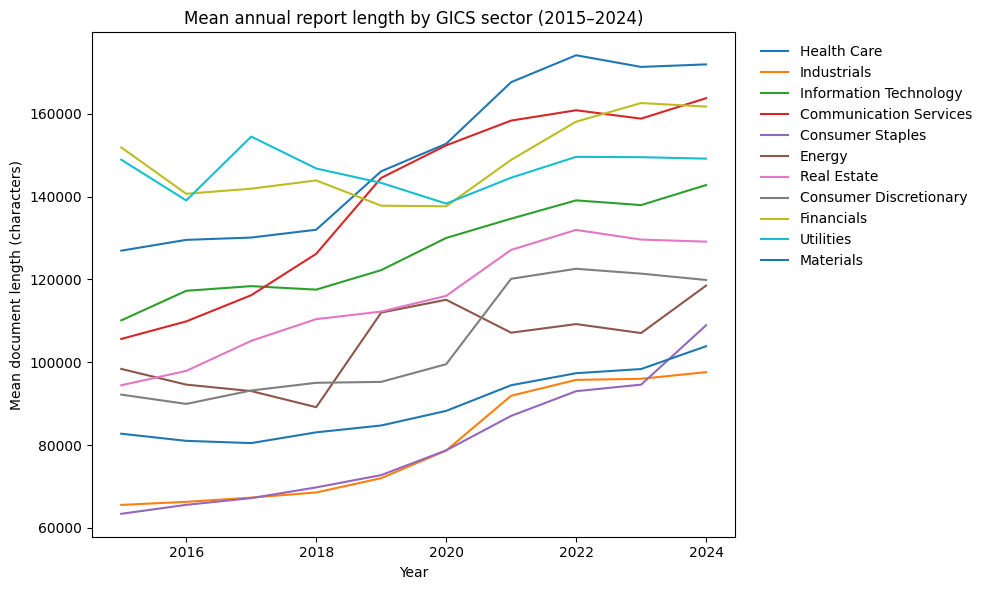

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for sector in sector_year_mean["gics_sector"].unique():
    df_s = sector_year_mean.filter(pl.col("gics_sector") == sector)
    plt.plot(df_s["year"], df_s["mean_doc_length"], label=sector)

plt.xlabel("Year")
plt.ylabel("Mean document length (characters)")
plt.title("Mean annual report length by GICS sector (2015–2024)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()


Mean annual report length increases across nearly all GICS sectors after 2020, indicating a structural shift in disclosure volume rather than firm-specific noise.

The relative ordering of sectors remains stable over time, suggesting persistent sector-level disclosure norms.

Utilities, Financials, and Health Care consistently exhibit the longest reports, reflecting higher regulatory and operational complexity.

Industrials and Consumer Staples remain comparatively concise, even following the post-2020 expansion.

The absence of post-2020 convergence implies that increased disclosure affected all sectors proportionally rather than homogenising reporting practices.

Volatility in Materials and Energy contrasts with smoother trajectories in other sectors, consistent with event-driven disclosure dynamics.

These patterns motivate sector-aware and length-normalised approaches to downstream TF-IDF and embedding-based ESG measurement.

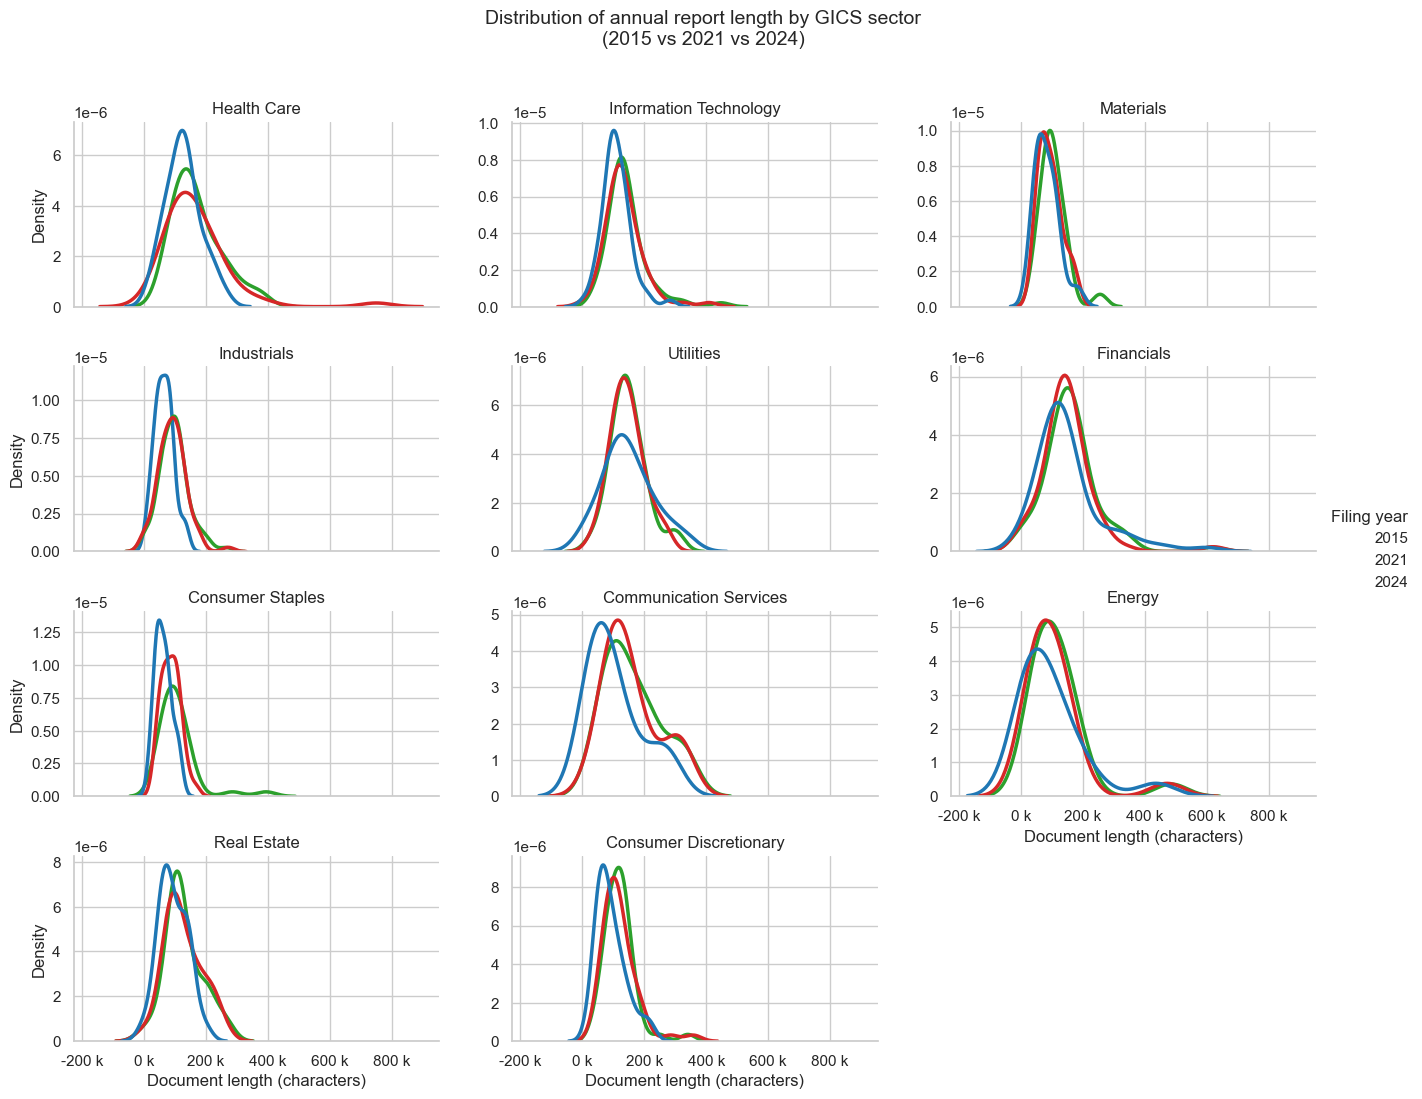

In [13]:
# What this cell does:
# - Same KDE facet plot as before
# - Uses a high-contrast, colour-blind-safe palette
# - Makes year overlays immediately distinguishable

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------------------
# Prep data
# --------------------
years_to_plot = [2015, 2021, 2024]

plot_df = (
    firm_year
    .filter(pl.col("year").is_in(years_to_plot))
    .select("gics_sector", "year", "doc_length")
    .to_pandas()
)

plot_df["year"] = plot_df["year"].astype(str)

# --------------------
# Axis formatter: 25000 -> 25 k
# --------------------
def thousands_formatter(x, pos):
    return f"{int(x/1000)} k"

# --------------------
# Explicit, high-contrast palette
# --------------------
year_palette = {
    "2015": "#1f77b4",  # strong blue
    "2021": "#d62728",  # strong red
    "2024": "#2ca02c",  # strong green
}

# --------------------
# Plot
# --------------------
sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    plot_df,
    col="gics_sector",
    col_wrap=3,
    height=2.8,
    aspect=1.6,
    sharex=True,
    sharey=False,
)

g.map_dataframe(
    sns.kdeplot,
    x="doc_length",
    hue="year",
    palette=year_palette,
    linewidth=2.5,          # slightly thicker lines
    common_norm=False,
)

# Apply axis formatting
for ax in g.axes.flatten():
    ax.xaxis.set_major_formatter(FuncFormatter(thousands_formatter))

g.add_legend(
    title="Filing year",
    label_order=["2015", "2021", "2024"],
)

g.set_axis_labels("Document length (characters)", "Density")
g.set_titles(col_template="{col_name}")

plt.subplots_adjust(top=0.88)
g.fig.suptitle(
    "Distribution of annual report length by GICS sector\n(2015 vs 2021 vs 2024)",
    fontsize=14,
)

plt.show()


The distributions of document length are highly right-skewed and bounded below at zero, exhibiting shapes consistent with gamma- or chi-square–type distributions rather than normality. The post-2020 expansion is therefore characterised by a thickening of the right tail, indicating that a growing subset of firms substantially increased disclosure volume, rather than a uniform increase across all firms.

Among the firms that are structurally the most verbose on average, how much of their disclosure volume is attributable to each benchmark year (2015, 2021, 2024)?

C:\Users\ddddd\AppData\Local\Temp\ipykernel_3804\281151805.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_wide.index, rotation=45, ha="right")


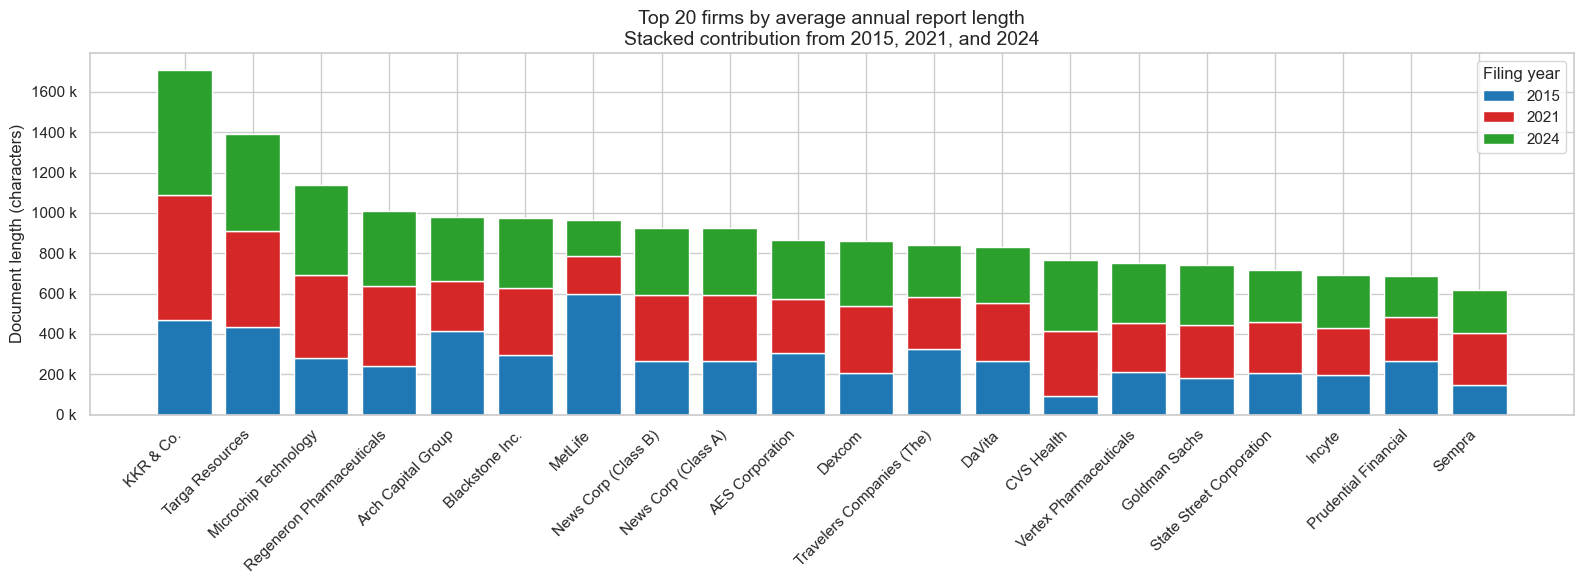

In [19]:
# What this cell does:
# - Pivots the prepared plot_df to wide format
# - Draws a stacked bar chart for 2015 / 2021 / 2024
# - Uses only firms with complete coverage (no holes)

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

years_to_plot = [2015, 2021, 2024]

# --------------------
# Pivot to wide (company × year)
# --------------------
plot_wide = (
    plot_df
    .pivot(index="company_name", columns="year", values="doc_length")
    .reindex(columns=years_to_plot)
)

# --------------------
# Sort by total size (descending)
# --------------------
plot_wide["total"] = plot_wide.sum(axis=1)
plot_wide = plot_wide.sort_values("total", ascending=False).drop(columns="total")

# --------------------
# Plot
# --------------------
fig, ax = plt.subplots(figsize=(16, 6))

bottom = pd.Series(0, index=plot_wide.index)

colors = {
    2015: "#1f77b4",  # blue
    2021: "#d62728",  # red
    2024: "#2ca02c",  # green
}

for year in years_to_plot:
    ax.bar(
        plot_wide.index,
        plot_wide[year],
        bottom=bottom,
        label=str(year),
        color=colors[year],
    )
    bottom += plot_wide[year]

# --------------------
# Formatting
# --------------------
ax.set_title(
    "Top 20 firms by average annual report length\n"
    "Stacked contribution from 2015, 2021, and 2024",
    fontsize=14,
)

ax.set_ylabel("Document length (characters)")
ax.legend(title="Filing year")

ax.set_xticklabels(plot_wide.index, rotation=45, ha="right")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x/1000)} k")
)

plt.tight_layout()
plt.show()


The ranking is stable: firms that are verbose in 2015 remain verbose in 2021 and 2024, which supports treating disclosure length as a structural firm characteristic, not a transient shock.

The post-2020 increase shows up as a thickening of the upper stacks, not a one-off spike, reinforcing the idea of persistent disclosure expansion.

Differences in stack composition reveal heterogeneous growth paths even among the most verbose firms — some expand steadily, others front-load or back-load disclosure growth.

The absence of gaps confirms that the balanced-panel restriction worked as intended and that differences reflect behaviour, not data availability.

Visually, this figure complements the sector plots: sectors explain baseline norms, while this explains firm-level persistence.

KKR’s filings are long because its asset-management and insurance businesses require extensive, mandatory risk and valuation disclosures.

Consolidation of complex investment vehicles and non-controlling interests greatly expands footnotes and segment reporting.

The persistence of this length across years indicates a structural reporting requirement, not episodic verbosity.

Annual report length exhibits a stable, right-skewed (chi-square-like) distribution, indicating that disclosure volume is structurally constrained rather than normally distributed.

From 2015 to 2024, disclosure length increases consistently across firms and sectors, with a clear post-2020 level shift that persists rather than reverting.

These findings justify treating document length as a confounding structural factor and motivate explicit length- and sector-aware normalisation in downstream ESG text analysis.